# Plotting light curves

/var/folders/l5/v5dnvp0s55qf8fr_xtcj80w80000gn/T/ipykernel_42699/3081265716.py:8: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  dfs = {os.path.basename(f): pd.read_csv(f, delim_whitespace=True, header=None).drop(columns=[3,4,5]).rename(columns={0:'Julian_Date',1:'Flux',2:'Error'}) for f in files}
/var/folders/l5/v5dnvp0s55qf8fr_xtcj80w80000gn/T/ipykernel_42699/3081265716.py:8: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  dfs = {os.path.basename(f): pd.read_csv(f, delim_whitespace=True, header=None).drop(columns=[3,4,5]).rename(columns={0:'Julian_Date',1:'Flux',2:'Error'}) for f in files}
/var/folders/l5/v5dnvp0s55qf8fr_xtcj80w80000gn/T/ipykernel_42699/3081265716.py:8: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep=

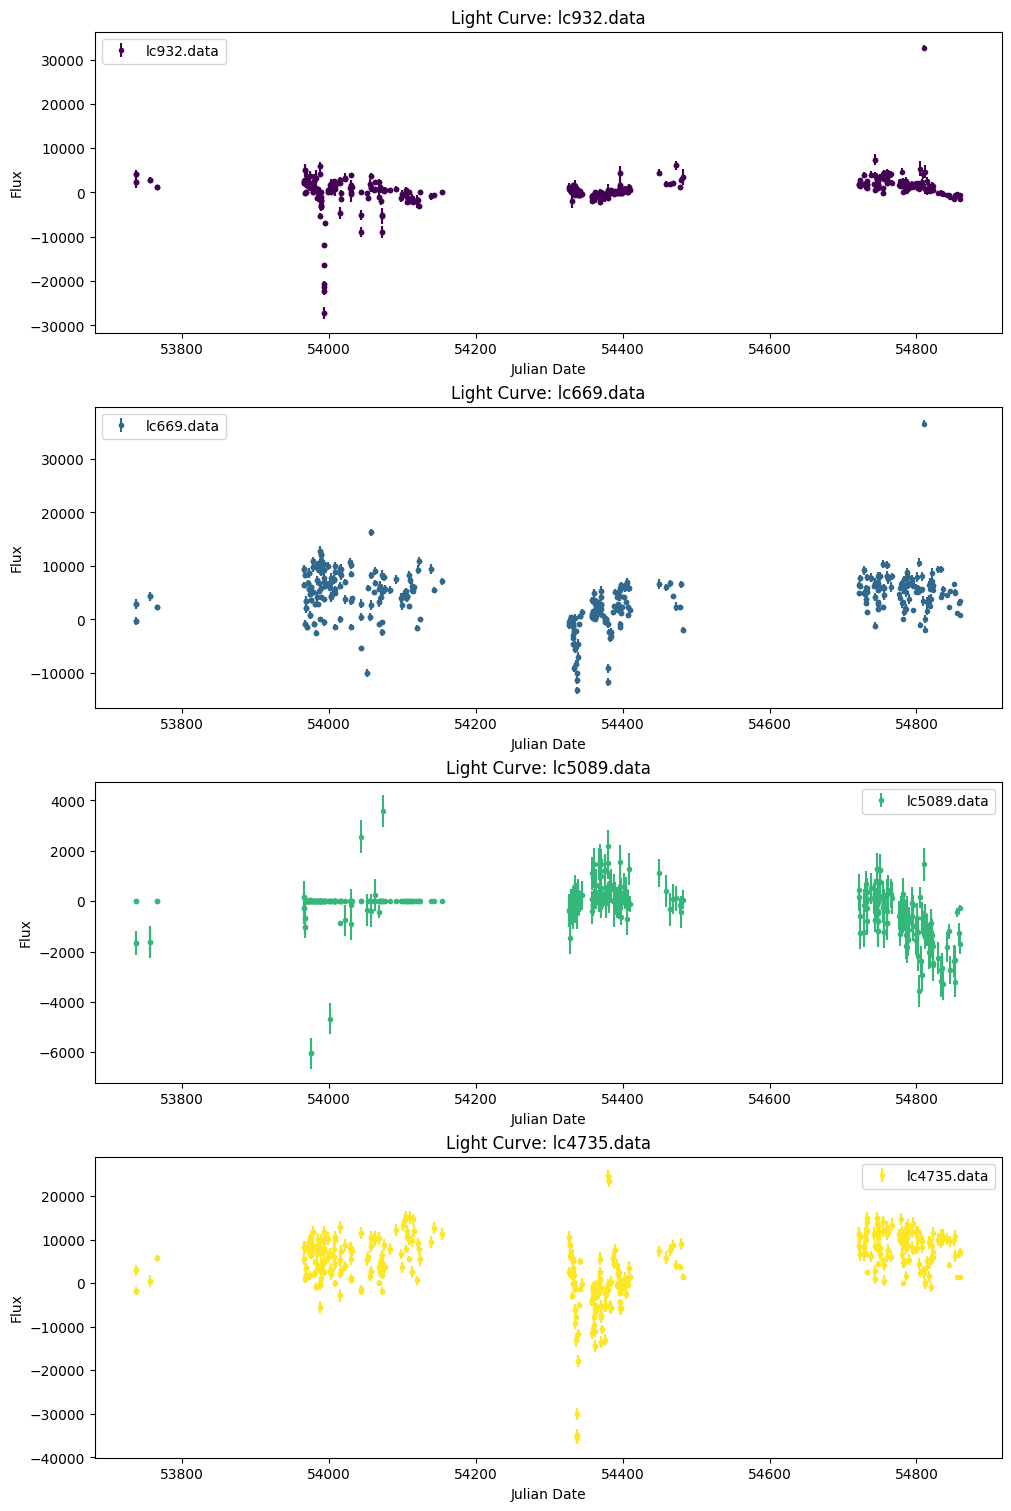

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob
import os
def getting_light_curves(path="light_curves/object_light_curves/"):
    files = glob.glob(path+"*.data")
    dfs = {os.path.basename(f): pd.read_csv(f, delim_whitespace=True, header=None).drop(columns=[3,4,5]).rename(columns={0:'Julian_Date',1:'Flux',2:'Error'}) for f in files}
    return dfs

def plotting_light_curves(ax,df,name,color):
    ax.errorbar(df['Julian_Date'], df['Flux'], yerr=df['Error'], fmt='.',color=color, label=name)
    ax.set_title(f'Light Curve: {name}')
    ax.set_xlabel('Julian Date')
    ax.set_ylabel('Flux')
    ax.legend()


dfs=getting_light_curves()

fig,ax=plt.subplots(4,figsize=(10,15),layout='constrained')
colors_viridis=plt.cm.viridis(np.linspace(0,1,len(ax)))

for i,(name,df) in enumerate(dfs.items()):
    plotting_light_curves(ax[i],df,name,color=colors_viridis[i])




/var/folders/l5/v5dnvp0s55qf8fr_xtcj80w80000gn/T/ipykernel_42699/3081265716.py:8: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  dfs = {os.path.basename(f): pd.read_csv(f, delim_whitespace=True, header=None).drop(columns=[3,4,5]).rename(columns={0:'Julian_Date',1:'Flux',2:'Error'}) for f in files}
/var/folders/l5/v5dnvp0s55qf8fr_xtcj80w80000gn/T/ipykernel_42699/3081265716.py:8: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  dfs = {os.path.basename(f): pd.read_csv(f, delim_whitespace=True, header=None).drop(columns=[3,4,5]).rename(columns={0:'Julian_Date',1:'Flux',2:'Error'}) for f in files}
/var/folders/l5/v5dnvp0s55qf8fr_xtcj80w80000gn/T/ipykernel_42699/3081265716.py:8: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep=

4


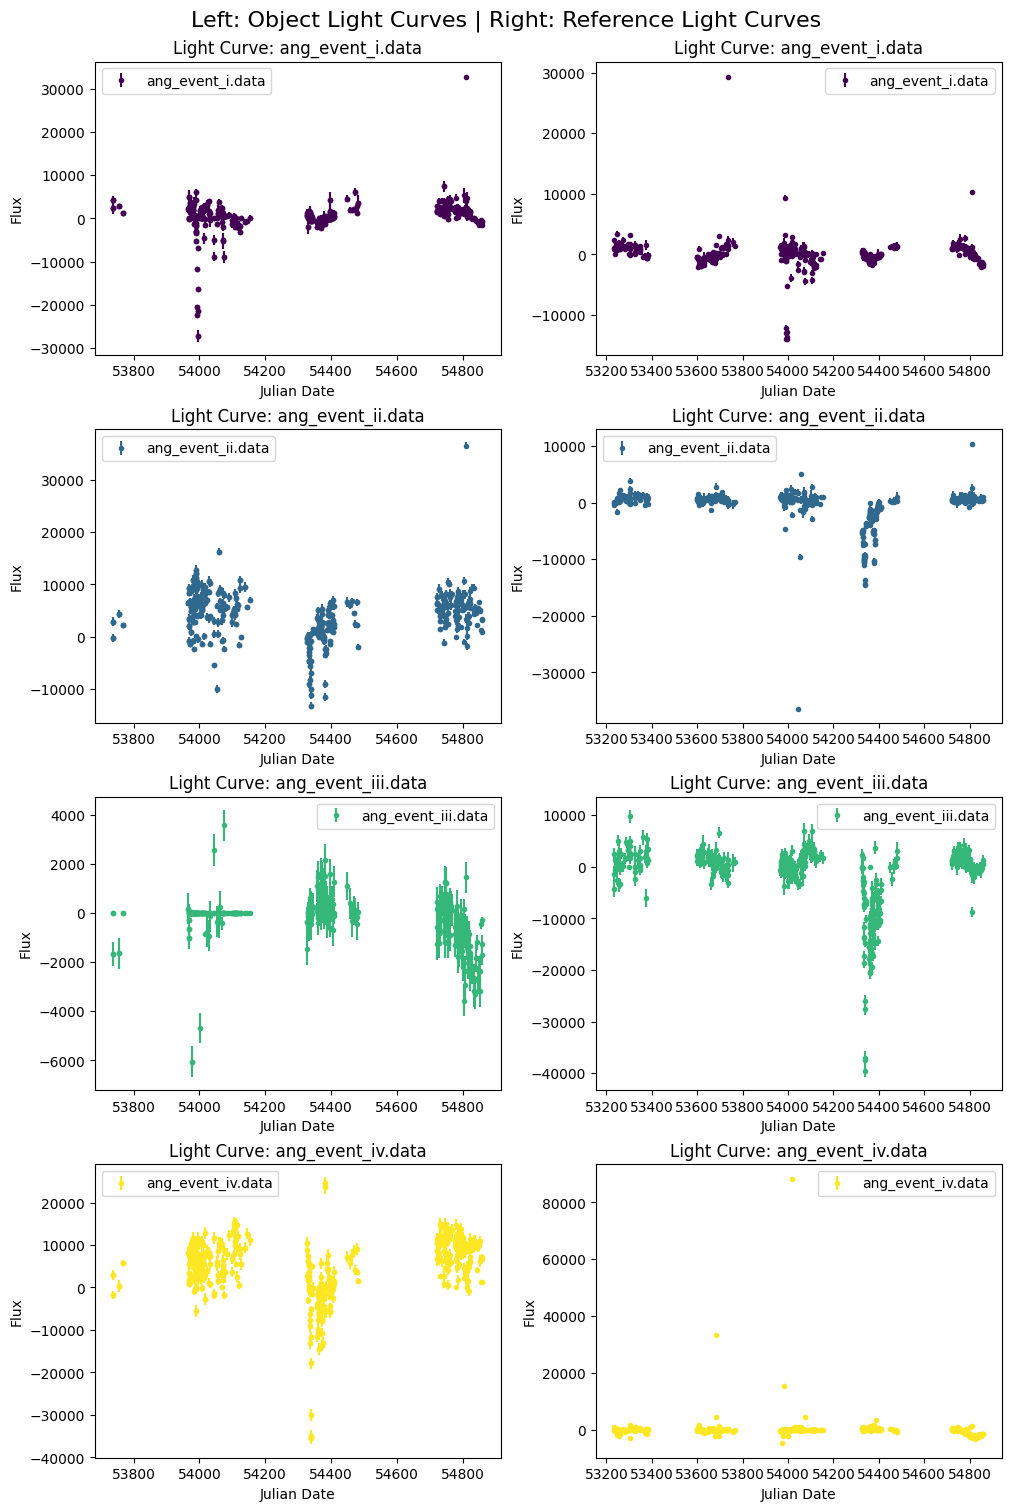

In [41]:
dfs=getting_light_curves()
dfs_reference=getting_light_curves("reference_light_curves/")
ordered_keys = sorted(dfs_reference.keys())
ordered_reference_dfs = {k:dfs_reference[k] for k in ordered_keys}

ig,ax=plt.subplots(4,2,figsize=(10,15),layout='constrained')
print(len(ax[:,0]))
colors_viridis=plt.cm.viridis(np.linspace(0,1,len(ax[:,0])))
plt.suptitle('Left: Object Light Curves | Right: Reference Light Curves', fontsize=16)

for i,((name1,df1),(name2,df_ref)) in enumerate(zip(dfs.items(),ordered_reference_dfs.items())):
    plotting_light_curves(ax[i][0],df1,name2,color=colors_viridis[i])
    plotting_light_curves(ax[i][1],df_ref,name2,color=colors_viridis[i])



# Fitting to PSF model

using the micro-1-2.param parameters we can fit the curves from ogle.

/var/folders/l5/v5dnvp0s55qf8fr_xtcj80w80000gn/T/ipykernel_42699/2326767535.py:11: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  dfs = {os.path.basename(f): pd.read_csv(f, delim_whitespace=True, header=None).drop(columns=[3,4]).rename(columns={0:'Julian_Date',1:'Flux',2:'Error'}) for f in files}
/var/folders/l5/v5dnvp0s55qf8fr_xtcj80w80000gn/T/ipykernel_42699/2326767535.py:11: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  dfs = {os.path.basename(f): pd.read_csv(f, delim_whitespace=True, header=None).drop(columns=[3,4]).rename(columns={0:'Julian_Date',1:'Flux',2:'Error'}) for f in files}
/Users/damianfrench/Desktop/labs/Microlensing/.venv/lib/python3.9/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwar

Fitted parameters for micro-2.dat: [ 2.45451694e+06  9.22257589e-02 -1.25919594e+00  1.85968914e+01
 -6.75793362e-02]
Fitted parameters for micro-1.dat: [2.45453928e+06 6.39884288e-02 2.04715675e+01 1.89043822e+01
 5.62946767e-01]


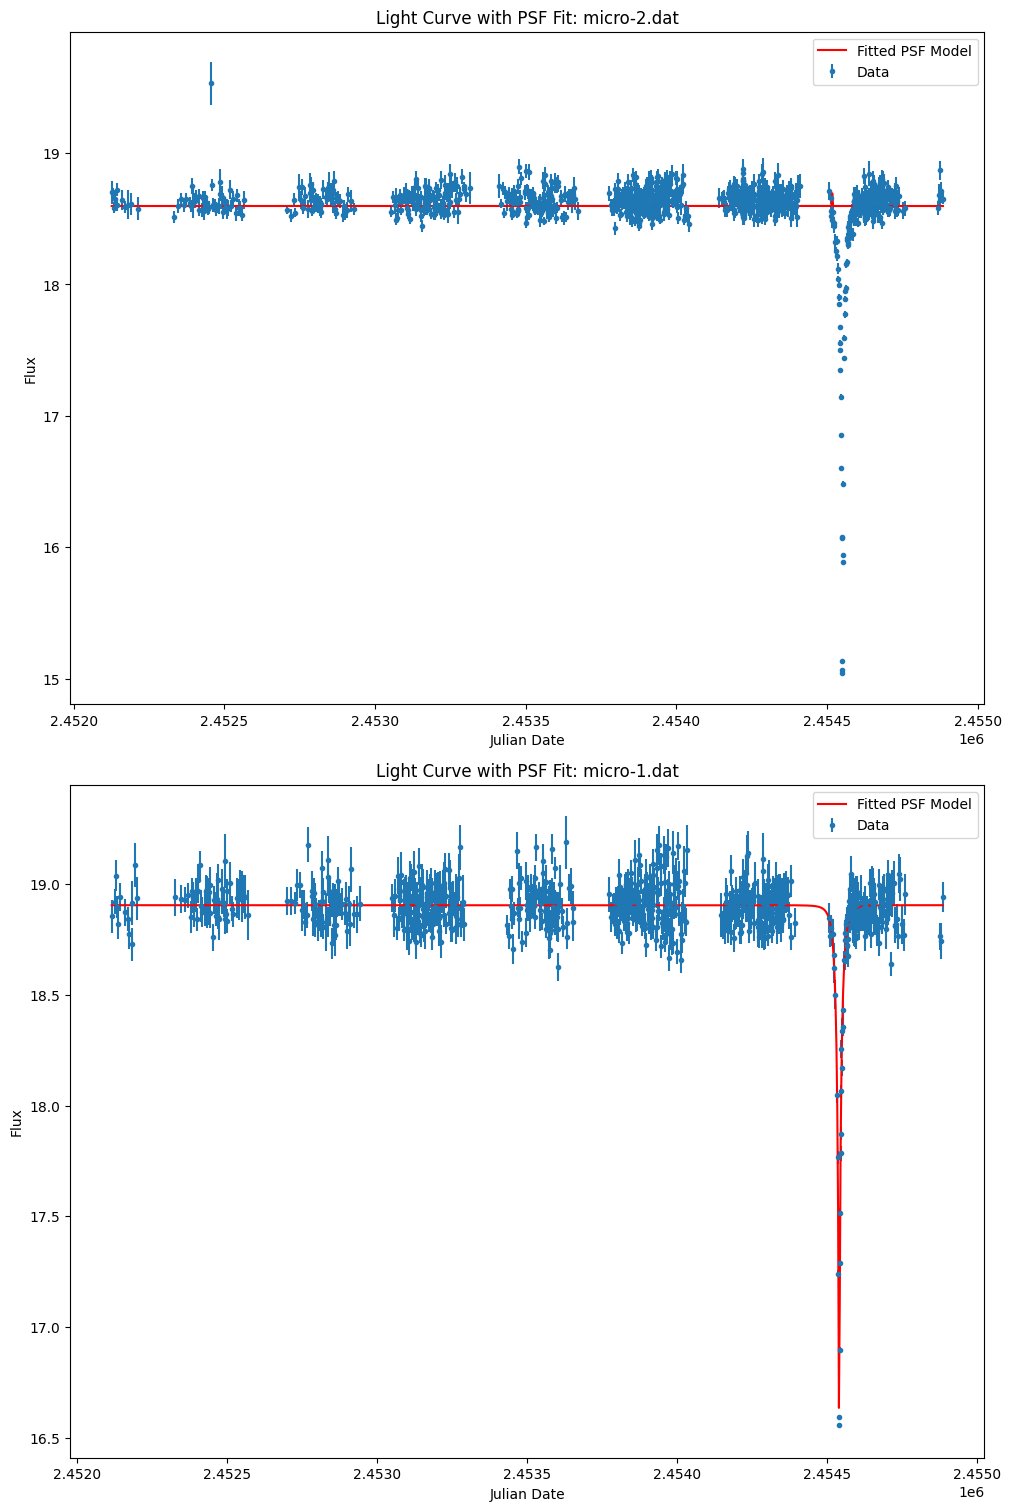

In [59]:
from scipy.optimize import curve_fit
def PSF(t,t_0,u_0,t_E,M_psf,F_b):
    """Point Source Point Lens model for microlensing light curves."""
    u = np.sqrt(u_0**2 + ((t-t_0)/t_E)**2)
    A = (u**2 + 2) / (u * np.sqrt(u**2 + 4))
    M=M_psf-2.5 * np.log10(F_b*A+(1-F_b))
    return M

def getting_light_curves_2(path="light_curves/object_light_curves/"):
    files = glob.glob(path+"*.dat")
    dfs = {os.path.basename(f): pd.read_csv(f, delim_whitespace=True, header=None).drop(columns=[3,4]).rename(columns={0:'Julian_Date',1:'Flux',2:'Error'}) for f in files}
    return dfs

dfs=getting_light_curves_2('ogle_light_curves/')
fig,ax=plt.subplots(2,figsize=(10,15),layout='constrained')
for i,(name,df) in enumerate(dfs.items()):
    p0 = [
    2454539.289,     # t_0: event time ~ middle of dataset
    0.063,                          # u_0: impact parameter, small but >0
    15.823,                           # t_E: Einstein radius crossing time (days)
    np.max(df['Flux']) - np.median(df['Flux']),  # F_s: source flux
    0.549        # F_b: blended flux
]

    try:
        
        t_fit = np.linspace(df['Julian_Date'].min(), df['Julian_Date'].max(), 1000)
        popt, pcov = curve_fit(PSF, df['Julian_Date'], df['Flux'], p0=p0)
        ax[i].errorbar(df['Julian_Date'], df['Flux'], yerr=df['Error'], fmt='.', label='Data')
        ax[i].plot(t_fit, PSF(t_fit, *popt), 'r-', label='Fitted PSF Model')
        ax[i].set_title(f'Light Curve with PSF Fit: {name}')
        ax[i].set_xlabel('Julian Date')
        ax[i].set_ylabel('Flux')
        ax[i].legend()
        print(f"Fitted parameters for {name}: {popt}")
    except RuntimeError as e:
        print(f"Could not fit data for {name}: {e}")
    